# Technical Report
## Data Generator (Following preprocessing.ipynb)

---

## 1. Pipeline Continuity

This notebook is a direct continuation of `preprocessing.ipynb`.

In the preprocessing step:
- Medical images were loaded (.nii)
- Slices were extracted
- Images were resized and normalized
- Data was saved as `.npy` files

This notebook uses those preprocessed `.npy` files to build a data generator for model training.


In [1]:
import os
import numpy as np


## 2. Data Loading and Generator Definition

This section defines how preprocessed data is loaded and prepared into batches.

The generator relies entirely on `.npy` files produced during preprocessing.


In [2]:
def load_img(img_dir, img_list):
    images = []
    for image_name in img_list:
        if image_name.endswith('.npy'):
            image = np.load(img_dir + image_name)
            images.append(image)
    return np.array(images)

def imageLoader(img_dir, img_list, mask_dir, mask_list, batch_size):
    L = len(img_list)
    while True:
        batch_start = 0
        batch_end = batch_size
        while batch_start < L:
            limit = min(batch_end, L)
            X = load_img(img_dir, img_list[batch_start:limit])
            Y = load_img(mask_dir, mask_list[batch_start:limit])
            yield (X, Y)
            batch_start += batch_size
            batch_end += batch_size


## 3. Generator Validation and Data Visualization

This section validates the data generator by retrieving a batch of images and masks, and performing a visual inspection.

### Purpose

After preprocessing and generator setup, it is essential to ensure that:

- Images are correctly loaded from `.npy` files  
- Modalities (FLAIR, T1ce, T2) are properly stacked  
- Masks are correctly aligned with the images  
- Data dimensions are consistent  

### Process

1. A batch is retrieved from the generator  
2. A random sample is selected from the batch  
3. The corresponding mask is converted using `argmax` to obtain class labels  
4. A random slice is selected  
5. The different MRI modalities and the segmentation mask are displayed  

### Why this is important

This step is a critical sanity check in the pipeline:

- Detects preprocessing errors early  
- Verifies correct channel ordering  
- Ensures masks correspond to the input images  
- Confirms the generator outputs usable training data  

This visual validation bridges the gap between preprocessing and model training.

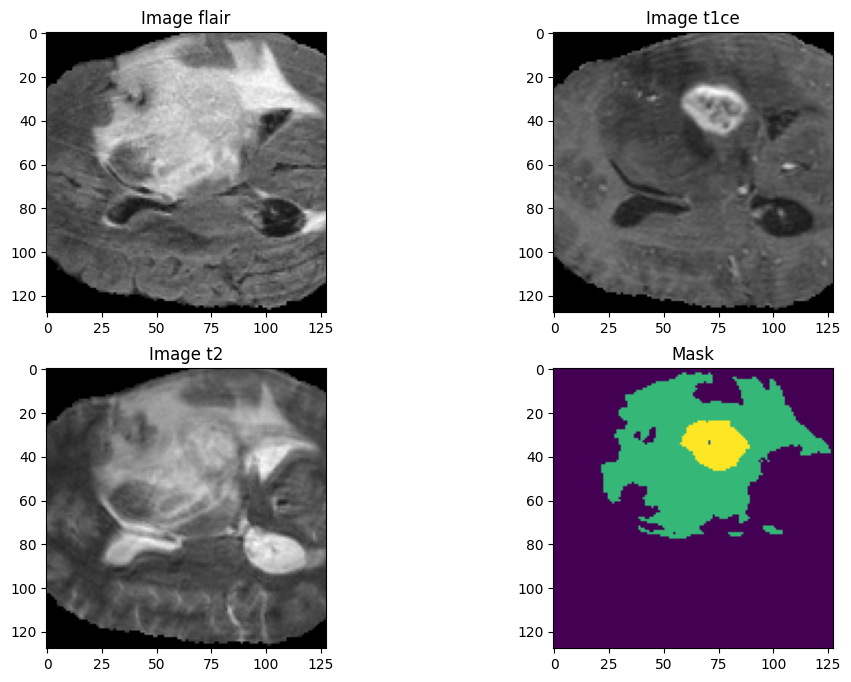

In [6]:
from matplotlib import pyplot as plt
import random

train_img_dir = "BraTS2020_TrainingData/input_data_128/train/images/"
train_mask_dir = "BraTS2020_TrainingData/input_data_128/train/masks/"

train_img_list = os.listdir(train_img_dir)
train_mask_list = os.listdir(train_mask_dir)

batch_size = 2

train_img_datagen = imageLoader(
    train_img_dir,
    train_img_list,
    train_mask_dir,
    train_mask_list,
    batch_size
)

# Verify generator
img, msk = next(train_img_datagen)

img_num = random.randint(0, img.shape[0] - 1)
test_img = img[img_num]
test_mask = msk[img_num]
test_mask = np.argmax(test_mask, axis=3)

n_slice = random.randint(0, test_mask.shape[2] - 1)
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:, :, n_slice, 0], cmap='gray')
plt.title('Image flair')

plt.subplot(222)
plt.imshow(test_img[:, :, n_slice, 1], cmap='gray')
plt.title('Image t1ce')

plt.subplot(223)
plt.imshow(test_img[:, :, n_slice, 2], cmap='gray')
plt.title('Image t2')

plt.subplot(224)
plt.imshow(test_mask[:, :, n_slice])
plt.title('Mask')

plt.show()